<a href="https://colab.research.google.com/github/yadavanushka266/Resume_Screening_System/blob/main/Resume_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Resume Screening System**

In today's competitive job market, organizations receive a large number of resumes for every job opening, making the recruitment process both time-consuming and resource-intensive. Recruiters are often required to manually review numerous applications to identify candidates who meet the required qualifications and skills. This traditional approach not only increases hiring time but also introduces the possibility of human error, inconsistency, and unconscious bias during the screening process.

With the rapid advancement of Machine Learning (ML) and Natural Language Processing (NLP), it has become possible to automate and enhance various stages of the recruitment process. This project presents a Machine Learning-based Resume Screening System that automatically analyzes resume content, extracts relevant information, and classifies resumes into appropriate job categories. By leveraging intelligent text processing and predictive algorithms, the system assists recruiters in efficiently shortlisting qualified candidates while improving the speed, accuracy, and consistency of resume evaluation.

**Introduction**

Resume screening is the process of evaluating candidates' resumes to identify those who best match the requirements of a job role. Automating this process using Machine Learning and Natural Language Processing (NLP) helps recruiters screen resumes more efficiently, accurately, and in less time.


**Techniques Used- Classification(K Nearest Neighbors)**

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used to classify resumes into predefined job categories. It predicts the category of a resume by comparing it with the K most similar resumes in the training dataset. Based on the majority class of the nearest neighbors, the system assigns the appropriate job category, enabling accurate and efficient resume screening.

**Importing Standard Libraries**

1.Numpy

2.Pandas

3.Matplotlib

4.Seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Loading the Dataset**

In [ ]:
df=pd.read_csv("Resume Screening.csv")

**Let's have a look at the columns in front**

In [ ]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


**Let's have a look at the columns at last**

In [ ]:
df.tail()

,Category,Resume
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
961,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...


**Viewing all the columns**

In [ ]:
df.columns

Index(['Category', 'Resume'], dtype='object')

**Shape of the dataset**

In [ ]:
df.shape

(962, 2)

**Retrieving the important information about the dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB


**Counting the unique category or job profile**

In [ ]:
df['Catgory'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


**Visualising the  different Categories**

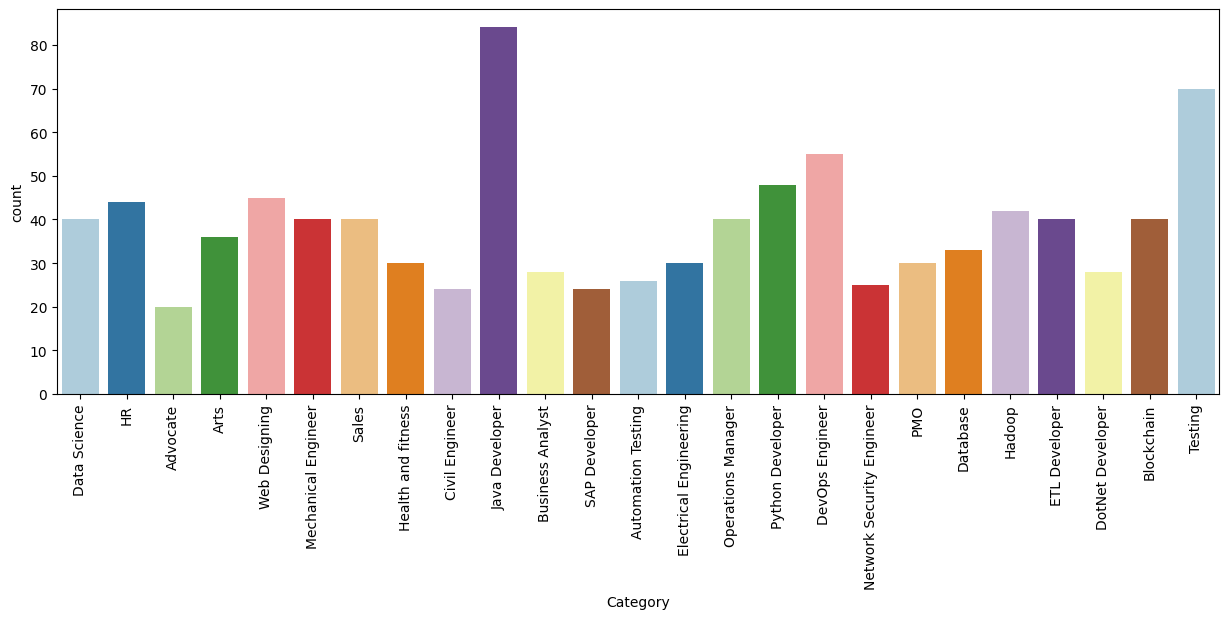

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x=df['Category'], hue=df['Category'], palette='Paired')
_ = plt.xticks(rotation=90)
plt.show()

**Exploratory Data Analysis**


**Viewing the unique Categories**

In [ ]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

**Visualising the distribution of the unique Category**

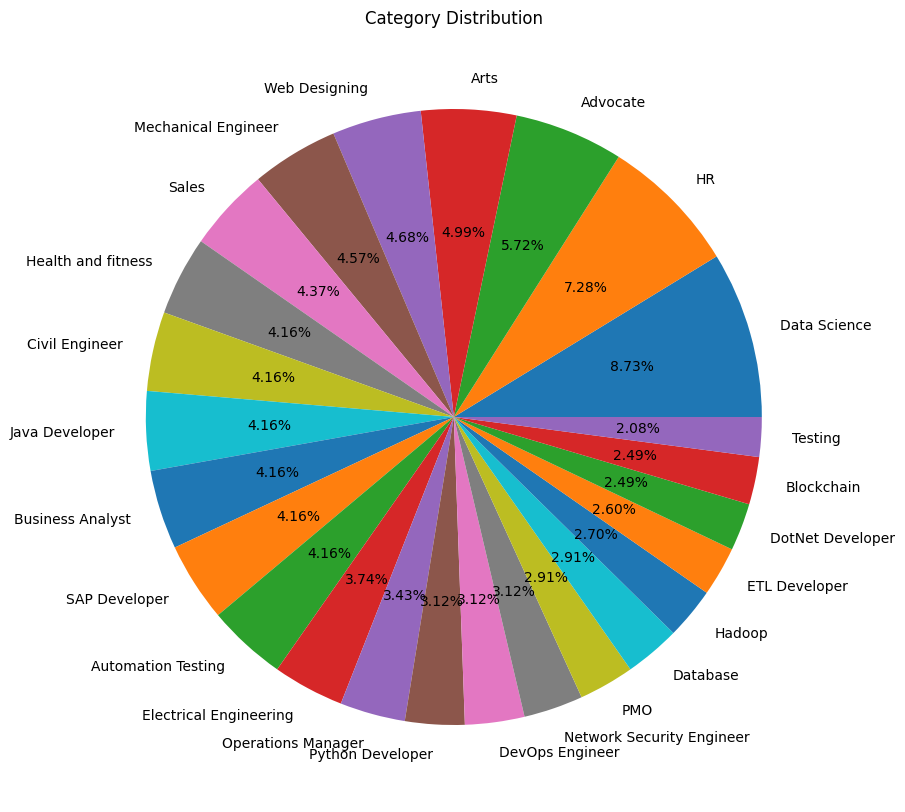

In [ ]:
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts,labels=labels,autopct='%1.2f%%')
plt.title('Category Distribution')
plt.show()

**Viewing the columns of the first row**

In [ ]:
df['Category'][0]

'Data Science'

In [ ]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

**Text preprocessing and Cleaning**

**Importing re and defining a function to return cleaned text after removing all the unwanted stuff**

In [ ]:
import re
def clean_resume(text):
  cleantext=re.sub(r'http\S+\s',' ',text)
  cleantext=re.sub(r'RT|cc',' ',cleantext)
  cleantext=re.sub(r'#\S+',' ',cleantext)
  cleantext=re.sub(r'@\S+',' ',cleantext)
  cleantext=re.sub(r'[%s]' % re.escape('''!"#$%&'()*+,-./:;<=>?@[]^_`{|}~'''),'',cleantext)
  cleantext=re.sub(r'\s+',' ',cleantext)
  cleantext=re.sub(r'[^\x00-\x7f]',' ',cleantext)
  cleantext=re.sub(r'Â',' ',cleantext)
  cleantext=re.sub(r'http\S+',' ',cleantext)
  return cleantext

**Viewing the Resume column to perform text cleaning on**

In [ ]:
df['Resume']

,Resume
0,Skills * Programming Languages: Python (pandas...
1,Education Details \r\nMay 2013 to May 2017 B.E...
2,"Areas of Interest Deep Learning, Control Syste..."
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...
957,Computer Skills: â¢ Proficient in MS office (...
958,â Willingness to accept the challenges. â ...
959,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


**Cleaning the Resume column**

In [ ]:
df['Resume']=df['Resume'].apply(lambda x: clean_resume(x))

**Viewing the first row of the Resume column after text cleaning**

In [ ]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikitlearn matplotlib Sql Java JavaScriptJQuery Machine learning Regression SVM Na  ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3js DCjs Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learningEducation Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the revi

**Importing Sklearn and converting categorical columns into numerical labels**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Category']=le.fit_transform(df['Category'])

**Viewing all the Categories in an alphabetical order**

In [ ]:
for i, category in enumerate(le.classes_):
    print(f"{category} {i}")

Advocate 0
Arts 1
Automation Testing 2
Blockchain 3
Business Analyst 4
Civil Engineer 5
Data Science 6
Database 7
DevOps Engineer 8
DotNet Developer 9
ETL Developer 10
Electrical Engineering 11
HR 12
Hadoop 13
Health and fitness 14
Java Developer 15
Mechanical Engineer 16
Network Security Engineer 17
Operations Manager 18
PMO 19
Python Developer 20
SAP Developer 21
Sales 22
Testing 23
Web Designing 24


**Printing the numerical value of the corresponding category**

In [ ]:
print(df['Category'])

0       6
1       6
2       6
3       6
4       6
       ..
957    23
958    23
959    23
960    23
961    23
Name: Category, Length: 962, dtype: int64


**Printing the corresponding numerical value of the category**

In [ ]:
df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

**Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',max_features=7566)
required_text=tfidf.fit_transform(df['Resume'])

In [ ]:
df

,Category,Resume
0,6,Skills Programming Languages Python pandas num...
1,6,Education Details May 2013 to May 2017 BE UITR...
2,6,Areas of Interest Deep Learning Control System...
3,6,Skills R Python SAP HANA Table...
4,6,Education Details MCA YMCAUST Faridabad Haryan...
...,...,...
957,23,Computer Skills Proficient in MS office Wo...
958,23,Willingness to a ept the challenges Po...
959,23,PERSONAL SKILLS Quick learner Eagernes...
960,23,COMPUTER SKILLS SOFTWARE KNOWLEDGE MSPower Poi...


In [ ]:
required_text

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164033 stored elements and shape (962, 7566)>

**Model Training**

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(required_text, df['Category'], test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(769, 7566)

In [ ]:
X_test.shape

(193, 7566)

**K-Nearest Neighbors Algorithm**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from  sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


In [ ]:
classifier= OneVsRestClassifier(KNeighborsClassifier())
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)
print(y_pred)

[15 15 15 13 14 17 16  2  0 14 13 12 16 23 20  5  6  4 10  9 19  1 10 23
 23 21 22 22  2 12 18  1  8 24 11 23  7 12 24  8 18  6  8 19 24 23 21  1
 15  4 15 22 11  5 15 13  1 19  5 12 22 22 20 24 21 18 12 10 10 20 10  8
  9 21 17 21  0 17 16 14 15 11 11  8 20  3 19  8  0  2  9 10  2 23 20 20
 23 12 18 12  7 16  8 14 18  3 14 19 14 14 15 18  8  2 21 18 23 10 23  5
 11 15 12  3  5  3  7 12 19  8 20 19  3 15  9 19  1 23 21  5 20 15 16  7
  7  8 15 18  1 15 13 20  7  4 18 11  5 15  5 12  9 22 18 21  8 23  4 12
 24 16 15 22  8 22  3 16 23 23 12  7 16 18  5  3 18  8 23 23 20 21  6  7
 23]


**Printing the Accuracy Score**

In [ ]:
print(accuracy_score(y_test,y_pred))

0.9844559585492227


**Model Prediction**

**Importing Pickle module and saving the model **

In [ ]:
import pickle

In [ ]:
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(classifier,open('classifier.pkl','wb'))


**Model Testing**

**Test Case 1**

In [ ]:
myresume="""#**RESUME**
## **Riya Sharma**
Advocate
Phone: 9198743210
Email [riyasharma@email.com](mailto:riyasharma@email.com)
Address: New Delhi, India
### **Professional Summary**
Dedicated and results-driven Advocate with over five years of experience in civil, criminal, family, and corporate law. Experienced in handling litigation, legal research, drafting legal documents, and representing clients before various courts and tribunals. Committed to delivering practical legal solutions while maintaining the highest standards of professionalism, ethics, and client confidentiality.
### **Professional Skills**
* Legal Research and Case Analysis
* Litigation and Court Representation
* Drafting Petitions, Affidavits, Contracts, and Agreements
* Client Counseling and Legal Consultation
* Civil, Criminal, Family, and Corporate Law
* Arbitration and Mediation
* Contract Review and Compliance
* Legal Documentation and Case Management
* Negotiation and Dispute Resolution
* Strong Communication and Analytical Skills
* Attention to Detail and Time Management
* Proficient in MS Office and Legal Research Tools
### **Professional Experience**
**Advocate**
**ABC & Associates, New Delhi**
**June 2020 – Present**
* Represent clients before District Courts and High Court in civil, criminal, and family law matters.
* Draft legal notices, petitions, affidavits, written statements, contracts, and agreements.
* Conduct legal research and prepare case strategies based on relevant statutes and judicial precedents.
* Advise clients on legal rights, obligations, and dispute resolution.
* Attend court hearings, client meetings, and settlement negotiations.
* Ensure compliance with legal procedures and maintain confidential case records.
**Junior Advocate**
**XYZ Law Chambers, New Delhi**
**July 2018 – May 2020**
* Assisted senior advocates in handling litigation matters.
* Conducted legal research and prepared legal briefs.
* Drafted pleadings, applications, and legal opinions.
* Coordinated with clients and collected case-related evidence.
* Assisted in court proceedings and case management.
### **Education**
**Bachelor of Laws (LL.B.)**
Faculty of Law, University of Delhi
2015 – 2018
**Bachelor of Arts (Political Science)**
University of Delhi
2012 – 2015
### **Internship**
**Legal Intern**
Senior Advocate, Supreme Court of India
January 2018 – April 2018
* Assisted in legal drafting and documentation.
* Conducted legal research and case law analysis.
* Observed court proceedings and assisted in case preparation.
### **Certifications**
* Certificate in Corporate Law
* Advanced Legal Drafting and Documentation
* Certificate in Arbitration and Mediation
### **Bar Council Registration**
Enrolled with the Bar Council of Delhi
Enrollment No.: D/1234/2018
### **Achievements**
* Successfully represented clients in more than 150 legal matters.
* Recognized for excellence in legal research and drafting.
* Achieved favorable outcomes in civil and family dispute cases through effective advocacy and negotiation.
### **Languages Known**
* English
* Hindi
### **Personal Details**
**Date of Birth:** 15 March 1994
**Nationality:** Indian
**Marital Status:** Single
### **Declaration**
I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.
**Place:** New Delhi
**(Riya Sharma)**"""



In [ ]:
classifier=pickle.load(open('classifier.pkl','rb'))
cleaned_resume=clean_resume(myresume)
input_features=tfidf.transform([cleaned_resume])
prediction_id=classifier.predict(input_features)[0]
print(prediction_id)
predicted_category_name = le.inverse_transform([prediction_id])[0]
print(f"Predicted Category: {predicted_category_name}")

0
Predicted Category: Advocate


**Match the above result with this output**

In [ ]:
for i, category in enumerate(le.classes_):
    print(f"{category} {i}")

Advocate 0
Arts 1
Automation Testing 2
Blockchain 3
Business Analyst 4
Civil Engineer 5
Data Science 6
Database 7
DevOps Engineer 8
DotNet Developer 9
ETL Developer 10
Electrical Engineering 11
HR 12
Hadoop 13
Health and fitness 14
Java Developer 15
Mechanical Engineer 16
Network Security Engineer 17
Operations Manager 18
PMO 19
Python Developer 20
SAP Developer 21
Sales 22
Testing 23
Web Designing 24


**Test Case 2**

In [ ]:


myresume="""# RESUME

## Priya Sharma

**Human Resources Executive**

**Phone:** +91 98765 43210
**Email:** [priyasharma@email.com](mailto:priyasharma@email.com)
**Address:** New Delhi, India
**LinkedIn:** linkedin.com/in/priyasharma

---

### Professional Summary

Motivated and detail-oriented Human Resources professional with over 4 years of experience in recruitment, employee relations, onboarding, performance management, payroll coordination, and HR operations. Skilled in talent acquisition, policy implementation, employee engagement, and maintaining compliance with labor laws. Adept at building positive workplace relationships and supporting organizational growth through effective human resource practices.

---

### Professional Skills

* Talent Acquisition and Recruitment
* Employee Onboarding and Orientation
* HR Policies and Compliance
* Performance Management
* Employee Relations and Conflict Resolution
* Payroll and Attendance Management
* Training and Development
* HRIS and Employee Database Management
* Resume Screening and Interview Coordination
* Compensation and Benefits Administration
* Communication and Interpersonal Skills
* Microsoft Office Suite (Excel, Word, PowerPoint)

---

### Professional Experience

**HR Executive**
**ABC Technologies Pvt. Ltd., New Delhi**
**July 2022 – Present**

* Managed end-to-end recruitment for technical and non-technical positions.
* Conducted candidate screening, interviews, and onboarding processes.
* Maintained employee records and HR documentation.
* Coordinated employee engagement activities and training sessions.
* Assisted in payroll processing, attendance tracking, and leave management.
* Ensured compliance with company policies and labor regulations.
* Addressed employee concerns and supported performance evaluation processes.

**HR Associate**
**XYZ Solutions Pvt. Ltd., Noida**
**June 2020 – June 2022**

* Assisted in recruitment and selection activities.
* Scheduled interviews and coordinated with hiring managers.
* Prepared offer letters, appointment letters, and employee contracts.
* Maintained HR databases and personnel files.
* Supported induction programs for new employees.
* Assisted in organizing training programs and employee welfare initiatives.

---

### Education

**Master of Business Administration (MBA) – Human Resource Management**
Amity University, Noida
2018 – 2020

**Bachelor of Business Administration (BBA)**
University of Delhi
2015 – 2018

---

### Certifications

* Certified Human Resource Professional (CHRP)
* Talent Acquisition and Recruitment Certification
* Advanced Microsoft Excel for HR
* HR Analytics Fundamentals

---

### Achievements

* Successfully recruited over 200 employees across multiple departments.
* Reduced average hiring time by 25% through streamlined recruitment processes.
* Organized employee engagement initiatives that improved workplace satisfaction.
* Recognized as "Best HR Performer" for outstanding contribution to recruitment and employee engagement.

---

### Languages

* English
* Hindi

---

### Personal Details

**Date of Birth:** 12 August 1996
**Nationality:** Indian
**Marital Status:** Single

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** New Delhi

**Date:** ___________

**(Priya Sharma)**
"""
tfidf_model = pickle.load(open('tfidf.pkl','rb'))
classifier_model = pickle.load(open('classifier.pkl','rb'))
label_encoder = joblib.load('label_encoder.pkl')
cleaned_new_resume = clean_resume(myresume)
vectorized_new_resume = tfidf_model.transform([cleaned_new_resume])
prediction_id_new = classifier_model.predict(vectorized_new_resume)[0]
predicted_category_name_new = label_encoder.inverse_transform([prediction_id_new])[0]
print(f"Predicted Category for the new resume: {predicted_category_name_new}")

Predicted Category for the new resume: HR


**Test Case 3**

In [ ]:
myresume="""# RESUME

## Rahul Verma

**Sales Executive**

**Phone:** +91 98765 43210
**Email:** [rahulverma@email.com](mailto:rahulverma@email.com)
**Address:** Mumbai, Maharashtra, India
**LinkedIn:** linkedin.com/in/rahulverma

---

### Professional Summary

Results-oriented Sales Executive with over 5 years of experience in business development, client relationship management, lead generation, and revenue growth. Proven ability to achieve and exceed sales targets through strategic planning, effective negotiation, and excellent customer service. Skilled in identifying market opportunities, maintaining long-term client relationships, and contributing to overall business growth.

---

### Professional Skills

*   Sales and Business Development
*   Lead Generation and Prospecting
*   Client Relationship Management
*   Negotiation and Closing Sales
*   Account Management
*   Customer Service and Support
*   Sales Forecasting and Reporting
*   Market Research and Competitive Analysis
*   Product Demonstration and Presentation
*   CRM Software (Salesforce, Zoho CRM)
*   Communication and Interpersonal Skills
*   Microsoft Office Suite (Excel, Word, PowerPoint)

---

### Professional Experience

**Sales Executive**
**ABC Solutions Pvt. Ltd., Mumbai**
**June 2021 – Present**

*   Achieved and consistently exceeded monthly and quarterly sales targets.
*   Identified new business opportunities through market research and networking.
*   Built and maintained strong relationships with key clients.
*   Conducted product presentations and negotiated contracts with customers.
*   Prepared sales reports, forecasts, and performance analyses.
*   Collaborated with marketing and customer support teams to improve customer satisfaction.

**Sales Associate**
**XYZ Enterprises, Pune**
**May 2019 – May 2021**

*   Generated qualified leads through outbound calls and client referrals.
*   Assisted customers in selecting products based on their business requirements.
*   Processed customer orders and maintained accurate sales records.
*   Followed up with clients to ensure satisfaction and encourage repeat business.
*   Supported senior sales managers in executing regional sales strategies.

---

### Education

**Bachelor of Business Administration (BBA)**
Savitribai Phule Pune University
2016 – 2019

---

### Certifications

*   Certified Sales Professional (CSP)
*   Customer Relationship Management (CRM) Certification
*   Advanced Sales and Negotiation Skills
*   Digital Marketing Fundamentals

---

### Achievements

*   Increased annual sales revenue by 30% through strategic client acquisition.
*   Successfully acquired over 100 new clients within two years.
*   Awarded "Top Sales Performer" for three consecutive quarters.
*   Maintained a customer retention rate of over 90%.

---

### Languages

*   English
*   Hindi
*   Marathi

---

### Personal Details

**Date of Birth:** 18 September 1997
**Nationality:** Indian
**Marital Status:** Single

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** Mumbai

**Date:** ___________

**(Rahul Verma)**
"""
cleaned_resume_current = clean_resume(myresume)
vectorized_resume_current = tfidf_model.transform([cleaned_resume_current])
prediction_id_current = classifier_model.predict(vectorized_resume_current)[0]
predicted_category_name_current = label_encoder.inverse_transform([prediction_id_current])[0]
print(f"Predicted Category for the resume: {predicted_category_name_current}")

Predicted Category for the resume: Sales


**Test Case 4**

In [ ]:
myresume="""# RESUME

## Neha Kapoor

**Health & Fitness Trainer**

**Phone:** +91 98765 43210
**Email:** [nehakapoor@email.com](mailto:nehakapoor@email.com)
**Address:** Bengaluru, Karnataka, India
**LinkedIn:** linkedin.com/in/nehakapoor

---

### Professional Summary

Passionate and certified Health & Fitness Trainer with over 5 years of experience in designing personalized fitness programs, conducting group training sessions, and promoting healthy lifestyle practices. Skilled in strength training, weight management, nutrition guidance, and injury prevention. Committed to helping clients achieve their fitness goals through motivation, education, and evidence-based training techniques.

---

### Professional Skills

* Personal Fitness Training
* Strength and Conditioning
* Weight Loss and Body Transformation Programs
* Nutrition and Wellness Guidance
* Group Fitness Instruction
* Cardiovascular and Functional Training
* Exercise Planning and Assessment
* Injury Prevention and Recovery Support
* Client Motivation and Coaching
* Health and Lifestyle Counseling
* First Aid and CPR Certified
* Excellent Communication and Interpersonal Skills

---

### Professional Experience

**Senior Fitness Trainer**
**FitLife Wellness Center, Bengaluru**
**June 2021 – Present**

* Developed customized fitness and wellness plans based on clients' goals and health conditions.
* Conducted one-on-one personal training and group fitness classes.
* Monitored client progress and adjusted exercise routines accordingly.
* Provided guidance on nutrition, weight management, and healthy lifestyle habits.
* Ensured proper use of gym equipment and maintained a safe workout environment.
* Assisted in organizing fitness workshops and wellness events.

**Fitness Trainer**
**Active Health Gym, Bengaluru**
**May 2019 – May 2021**

* Assisted clients with exercise techniques and fitness assessments.
* Designed beginner and intermediate workout programs.
* Conducted yoga, HIIT, and strength training sessions.
* Motivated members to achieve their fitness goals through regular follow-ups.
* Maintained accurate records of client progress and attendance.

---

### Education

**Bachelor of Science (B.Sc.) in Physical Education**
Bangalore University
2016 – 2019

---

### Certifications

* Certified Personal Trainer (CPT)
* CPR and First Aid Certification
* Sports Nutrition Certification
* Functional Training Specialist
* Group Fitness Instructor Certification

---

### Achievements

* Successfully trained over 300 clients with personalized fitness programs.
* Helped clients achieve an average weight loss of 10–15 kg through structured fitness and nutrition plans.
* Awarded "Best Fitness Trainer of the Year" for exceptional client satisfaction.
* Organized corporate wellness and fitness awareness programs for leading organizations.

---

### Languages

* English
* Hindi
* Kannada

---

### Personal Details

**Date of Birth:** 08 February 1995
**Nationality:** Indian
**Marital Status:** Single

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** Bengaluru

**Date:** ___________

**(Neha Kapoor)**"""
cleaned_resume_current = clean_resume(myresume)
vectorized_resume_current = tfidf_model.transform([cleaned_resume_current])
prediction_id_current = classifier_model.predict(vectorized_resume_current)[0]
predicted_category_name_current = label_encoder.inverse_transform([prediction_id_current])[0]
print(f"Predicted Category for the resume: {predicted_category_name_current}")

Predicted Category for the resume: Health and fitness


**Test Case 5**

In [ ]:
myresume="""# RESUME

## Arjun Mehta

**Blockchain Developer**

**Phone:** +91 98765 43210
**Email:** [arjunmehta@email.com](mailto:arjunmehta@email.com)
**Address:** Hyderabad, Telangana, India
**LinkedIn:** linkedin.com/in/arjunmehta
**GitHub:** github.com/arjunmehta

---

### Professional Summary

Innovative Blockchain Developer with 4+ years of experience in designing, developing, and deploying decentralized applications (DApps), smart contracts, and blockchain-based solutions. Proficient in Ethereum, Solidity, Web3 technologies, and blockchain architecture. Experienced in building secure, scalable, and efficient decentralized systems while collaborating with cross-functional teams to deliver high-quality products.

---

### Professional Skills

* Blockchain Development
* Smart Contract Development (Solidity)
* Ethereum and EVM-Based Networks
* Decentralized Applications (DApps)
* Web3.js and Ethers.js
* NFT and Token Development (ERC-20, ERC-721, ERC-1155)
* Blockchain Security and Auditing
* Hyperledger Fabric
* Cryptography and Consensus Mechanisms
* JavaScript, TypeScript, Python
* Node.js and React.js
* Git, GitHub, and CI/CD
* Problem Solving and Analytical Thinking

---

### Professional Experience

**Blockchain Developer**
**BlockTech Solutions Pvt. Ltd., Hyderabad**
**June 2022 – Present**

* Designed and deployed smart contracts on Ethereum and Polygon networks.
* Developed decentralized applications using React.js, Solidity, and Web3 technologies.
* Conducted smart contract testing, debugging, and optimization.
* Collaborated with security teams to identify and mitigate vulnerabilities.
* Integrated blockchain functionality with existing web applications.
* Participated in code reviews and technical architecture discussions.

**Junior Blockchain Developer**
**Crypto Innovations Pvt. Ltd., Bengaluru**
**July 2020 – May 2022**

* Assisted in developing and maintaining blockchain-based applications.
* Created and tested smart contracts using Solidity.
* Worked on token creation, wallet integration, and transaction processing.
* Performed blockchain data analysis and troubleshooting.
* Contributed to project documentation and technical support.

---

### Education

**Bachelor of Technology (B.Tech) – Computer Science and Engineering**
Jawaharlal Nehru Technological University (JNTU)
2016 – 2020

---

### Technical Projects

**Decentralized Voting System**

* Developed a blockchain-based voting platform using Ethereum and Solidity.
* Implemented secure voting mechanisms and transparent vote counting.
* Integrated MetaMask wallet authentication.

**NFT Marketplace**

* Built an NFT marketplace supporting minting, buying, and selling digital assets.
* Implemented ERC-721 smart contracts and IPFS storage integration.

**Supply Chain Tracking System**

* Developed a blockchain solution for tracking products across the supply chain.
* Enhanced transparency and traceability using distributed ledger technology.

---

### Certifications

* Certified Blockchain Developer
* Ethereum and Solidity Developer Certification
* Hyperledger Fabric Fundamentals
* Blockchain Security and Smart Contract Auditing

---

### Achievements

* Successfully deployed multiple production-grade smart contracts.
* Reduced smart contract execution costs through optimization techniques.
* Recognized for developing secure and scalable blockchain solutions.
* Contributed to open-source blockchain projects and developer communities.

---

### Languages

* English
* Hindi
* Telugu

---

### Personal Details

**Date of Birth:** 15 May 1998
**Nationality:** Indian
**Marital Status:** Single

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** Hyderabad

**Date:** ___________

**(Arjun Mehta)**"""
cleaned_resume_current = clean_resume(myresume)
vectorized_resume_current = tfidf_model.transform([cleaned_resume_current])
prediction_id_current = classifier_model.predict(vectorized_resume_current)[0]
predicted_category_name_current = label_encoder.inverse_transform([prediction_id_current])[0]
print(f"Predicted Category for the resume: {predicted_category_name_current}")


Predicted Category for the resume: Blockchain


**Test Case 6**

In [ ]:
myresume="""# RESUME

## Rohit Sharma

**Civil Engineer**

**Phone:** +91 98765 43210
**Email:** [rohitsharma@email.com](mailto:rohitsharma@email.com)
**Address:** Pune, Maharashtra, India
**LinkedIn:** linkedin.com/in/rohitsharma

---

### Professional Summary

Dedicated and detail-oriented Civil Engineer with over 5 years of experience in planning, designing, supervising, and executing residential, commercial, and infrastructure projects. Skilled in project management, structural analysis, site supervision, quality assurance, and construction planning. Proficient in engineering software and committed to delivering projects that meet safety, quality, and budget requirements.

---

### Professional Skills

* Structural Design and Analysis
* Construction Planning and Site Supervision
* Project Management
* AutoCAD, Civil 3D, STAAD.Pro, and Revit
* Quantity Surveying and Estimation
* Surveying and Land Measurement
* Quality Control and Assurance
* Contract Administration
* Building Codes and Safety Regulations
* Cost Estimation and Budget Management
* Problem Solving and Technical Documentation
* Team Leadership and Communication

---

### Professional Experience

**Civil Engineer**
**ABC Construction Pvt. Ltd., Pune**
**June 2021 – Present**

* Supervised residential and commercial construction projects from planning to completion.
* Prepared project schedules, cost estimates, and construction reports.
* Coordinated with architects, contractors, and clients to ensure timely project delivery.
* Conducted site inspections to maintain quality standards and compliance with safety regulations.
* Monitored material usage and managed project budgets effectively.
* Reviewed engineering drawings and resolved technical issues at construction sites.

**Site Engineer**
**XYZ Infrastructure Ltd., Mumbai**
**July 2019 – May 2021**

* Assisted in supervising daily construction activities.
* Managed site labor, materials, and equipment.
* Prepared quantity estimates and maintained project documentation.
* Ensured compliance with construction standards and government regulations.
* Conducted quality inspections and prepared progress reports.

---

### Education

**Bachelor of Technology (B.Tech) – Civil Engineering**
Savitribai Phule Pune University
2015 – 2019

---

### Technical Projects

**Multi-Storey Residential Building Design**

* Designed structural components for a G+10 residential building.
* Performed load calculations and structural analysis using STAAD.Pro.
* Prepared detailed engineering drawings using AutoCAD.

**Highway Drainage Improvement Project**

* Assisted in the design and execution of an urban drainage system.
* Conducted site surveys and prepared cost estimates.
* Coordinated with contractors to ensure timely project completion.

---

### Certifications

* AutoCAD Professional Certification
* STAAD.Pro Structural Analysis Certification
* Primavera P6 Project Planning Certification
* Construction Safety Management Certification

---

### Achievements

* Successfully completed multiple residential and commercial construction projects within budget and schedule.
* Improved construction efficiency through effective planning and resource management.
* Recognized for maintaining high standards of quality and workplace safety.
* Awarded "Best Site Engineer" for outstanding project execution and team coordination.

---

### Languages

* English
* Hindi
* Marathi

---

### Personal Details

**Date of Birth:** 22 September 1996
**Nationality:** Indian
**Marital Status:** Single

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** Pune

**Date:** ___________

**(Rohit Sharma)**"""
cleaned_resume_current = clean_resume(myresume)
vectorized_resume_current = tfidf_model.transform([cleaned_resume_current])
prediction_id_current = classifier_model.predict(vectorized_resume_current)[0]
predicted_category_name_current = label_encoder.inverse_transform([prediction_id_current])[0]
print(f"Predicted Category for the resume: {predicted_category_name_current}")



Predicted Category for the resume: Civil Engineer


Test Case 7

In [ ]:
myresume="""# RESUME

## *Ananya Sharma**

**Machine Learning Engineer**

**Phone:** +913409876
**Email:** [sharmaananya@email.com](mailto:sharmaananya@email.com)
**Address:** Ahmedabad, India
**LinkedIn:** linkedin.com/in/ananyasharma
**GitHub:** github.com/ananyasharma234

---

### Professional Summary

Innovative and results-driven Machine Learning Engineer with expertise in designing, developing, and deploying intelligent machine learning solutions. Proficient in Python, TensorFlow, Scikit-learn, deep learning, computer vision, and data analysis. Skilled in building predictive models, recommendation systems, and AI-powered applications with a strong foundation in data preprocessing, feature engineering, model optimization, and deployment. Passionate about solving real-world problems through artificial intelligence and continuous learning.

---

### Professional Skills

* Machine Learning & Deep Learning
* Python Programming
* TensorFlow, Keras & Scikit-learn
* Computer Vision
* Natural Language Processing (NLP)
* Data Preprocessing & Feature Engineering
* Model Evaluation & Hyperparameter Tuning
* Data Analysis using Pandas & NumPy
* Data Visualization (Matplotlib, Power BI)
* SQL & Database Management
* FastAPI & Flask
* Git & GitHub
* Docker (Basics)
* Problem Solving & Analytical Thinking

---

### Professional Experience

**Machine Learning Engineer**
**AI Tech Solutions Pvt. Ltd., Bengaluru**
**June 2023 – Present**

* Developed and deployed machine learning models for predictive analytics and recommendation systems.
* Built deep learning models for image classification and object recognition using TensorFlow and Keras.
* Performed data cleaning, preprocessing, and feature engineering on large datasets.
* Optimized model performance through hyperparameter tuning and cross-validation.
* Deployed machine learning models using FastAPI and Docker.
* Collaborated with software developers to integrate AI models into production applications.

**Machine Learning Intern**
**DataVision Analytics Pvt. Ltd., Noida**
**January 2023 – May 2023**

* Assisted in developing classification and regression models.
* Conducted exploratory data analysis and feature selection.
* Built dashboards to visualize model performance.
* Supported model testing and documentation.

---

### Education

**Bachelor of Technology (B.Tech) – Computer Science and Engineering**
ABC College of Engineering, Surat
2023 – 2027

---

### Technical Projects

**Emotion Recognition from Facial Expressions**

* Developed a deep learning model using Convolutional Neural Networks (CNNs) to classify emotions from facial images.
* Achieved high accuracy on a public facial expression dataset.
* Implemented real-time emotion detection using OpenCV.

**Customer Churn Prediction**

* Built a predictive model to identify customers at risk of churning for a telecom company.
* Used machine learning algorithms like Logistic Regression and Random Forest.
* Identified key features influencing churn and provided actionable insights for retention strategies.

---

### Certifications

* Machine Learning with Python
* Deep Learning Fundamentals
* Python for Data Science
* SQL for Data Analytics

---

### Achievements

* Developed and deployed multiple machine learning projects, including recommendation systems and fake news detection.
* Achieved high prediction accuracy through effective feature engineering and model optimization.
* Strong understanding of machine learning algorithms, deep learning, and AI model deployment.
* Actively participates in technical projects and continuously explores emerging AI technologies.

---

### Languages

* English
* Hindi

---

### Personal Details

**Date of Birth:** 04/05/2005
**Nationality:** Indian

---

### Declaration

I hereby declare that the information provided above is true and correct to the best of my knowledge and belief.

**Place:** Ghaziabad

**Date:** ___________

**(Ananya Sharma)**
"""
cleaned_resume_current = clean_resume(myresume)
vectorized_resume_current = tfidf_model.transform([cleaned_resume_current])
prediction_id_current = classifier_model.predict(vectorized_resume_current)[0]
predicted_category_name_current = label_encoder.inverse_transform([prediction_id_current])[0]
print(f"Predicted Category for the resume: {predicted_category_name_current}")

Predicted Category for the resume: Data Science


**Importing joblib**

In [ ]:
import joblib

**Saving the model**

In [ ]:
joblib.dump(le,'label_encoder.pkl')

['label_encoder.pkl']

**Conclusion**

The Resume Screening System demonstrates how Machine Learning can automate the process of analyzing and classifying resumes efficiently. By utilizing Natural Language Processing (NLP), TF-IDF feature extraction, and the K-Nearest Neighbors (KNN) algorithm, the system predicts the most suitable job category based on resume content. This approach reduces manual effort, saves screening time, and helps recruiters shortlist candidates more accurately and consistently.